In [ ]:

from vllm import SamplingParams
from vllm.engine.arg_utils import AsyncEngineArgs
from vllm.v1.engine.async_llm import AsyncLLM

import torch

type_str = "float32"
torch_type = getattr(torch, type_str)
engine_args = AsyncEngineArgs(
    model="toy_conv",
    dtype=type_str,
    max_model_len=64,
    gpu_memory_utilization=0.05,
    skip_tokenizer_init=True,
    enable_prefix_caching=False,
    #load_format="dummy",
    block_size=128,
    #enforce_eager=True,
)
engine = AsyncLLM.from_engine_args(engine_args)
sampling_params = SamplingParams(max_tokens=64, skip_sampling=True)


request_id = "1"

# random input:
# T_target x Factor * Freq * Channels
t_target = 50
factor = 2
freq = 80
channels = 256
x = torch.randn(
    t_target, factor * freq * channels,
    dtype=torch_type
)

prompt_len = 4
i = 0
inputs = {
    # dummy tokens
    "prompt_token_ids": [0] * prompt_len,
    # actual inpust to the model in prefill stage
    "custom_inputs": {
        "conv_input": x[i:i+prompt_len]
    }
}
i += prompt_len
outputs = []
async for output in engine.generate(inputs, sampling_params=sampling_params, request_id=request_id):
    conv_output = output.outputs[0].custom_outputs["conv_output"]  # T_target x Factor/2 x Freq/2 x Channels
    print(conv_output.shape)
    outputs.append(conv_output)
    if i >= x.shape[0]:
        break
    inputs = {"conv_input": x[i:i+1]}
    i += 1
    await engine.append_request(request_id=request_id, custom_inputs=inputs)

/home/vklimkov/miniconda3/envs/vllm/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/vklimkov/miniconda3/envs/vllm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO 12-23 13:55:08 [__init__.py:224] Automatically detected platform cuda.
INFO 12-23 13:55:08 [model.py:655] Resolved architecture: ToyConv


`torch_dtype` is deprecated! Use `dtype` instead!


ERROR 12-23 13:55:09 [config.py:299] Error retrieving safetensors: 'toy_conv' is not a safetensors repo. Couldn't find 'model.safetensors.index.json' or 'model.safetensors' files., retrying 1 of 2
ERROR 12-23 13:55:11 [config.py:297] Error retrieving safetensors: 'toy_conv' is not a safetensors repo. Couldn't find 'model.safetensors.index.json' or 'model.safetensors' files.
INFO 12-23 13:55:11 [model.py:1731] Using max model len 64


2025-12-23 13:55:11,413	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


...

(EngineCore_DP0 pid=505557) INFO 12-23 13:55:12 [parallel_state.py:1231] rank 0 in world size 1 is assigned as DP rank 0, PP rank 0, TP rank 0, EP rank 0
(EngineCore_DP0 pid=505557) INFO 12-23 13:55:12 [topk_topp_sampler.py:59] Using FlashInfer for top-p & top-k sampling.
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
(EngineCore_DP0 pid=505557) INFO 12-23 13:55:12 [gpu_model_runner.py:3014] Starting to load model toy_conv...
(EngineCore_DP0 pid=505557) INFO 12-23 13:55:13 [gpu_model_runner.py:30

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00, 1567.38it/s]
(EngineCore_DP0 pid=505557) 


(EngineCore_DP0 pid=505557) INFO 12-23 13:55:13 [default_loader.py:309] Loading weights took 0.00 seconds
(EngineCore_DP0 pid=505557) INFO 12-23 13:55:13 [gpu_model_runner.py:3076] Model loading took 0.0000 GiB and 0.026223 seconds
(EngineCore_DP0 pid=505557) INFO 12-23 13:55:13 [backends.py:594] Using cache directory: /home/vklimkov/.cache/vllm/torch_compile_cache/4f86248c0e/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=505557) INFO 12-23 13:55:13 [backends.py:608] Dynamo bytecode transform time: 0.17 s
(EngineCore_DP0 pid=505557) INFO 12-23 13:55:13 [backends.py:179] Directly load the compiled graph(s) for dynamic shape from the cache, took 0.017 s
(EngineCore_DP0 pid=505557) INFO 12-23 13:55:13 [monitor.py:33] torch.compile takes 0.17 s in total
(EngineCore_DP0 pid=505557) INFO 12-23 13:55:14 [gpu_worker.py:314] Available KV cache memory: 2.27 GiB
(EngineCore_DP0 pid=505557) INFO 12-23 13:55:14 [kv_cache_utils.py:1133] GPU KV cache size: 4,647 tokens
(EngineCore_DP0

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 35/35 [00:00<00:00, 1534.61it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 19/19 [00:00<00:00, 119.23it/s]


(EngineCore_DP0 pid=505557) INFO 12-23 13:55:14 [gpu_model_runner.py:3974] Graph capturing finished in 0 secs, took 0.02 GiB
(EngineCore_DP0 pid=505557) INFO 12-23 13:55:14 [core.py:237] init engine (profile, create kv cache, warmup model) took 1.34 seconds
INFO 12-23 13:55:14 [loggers.py:148] Engine 000: vllm cache_config_info with initialization after num_gpu_blocks is: 4647
WARNING 12-23 13:55:14 [async_llm.py:283] Processor has been moved under OpenAIServing and will be removed from AsyncLLM in v0.13.
WARNING 12-23 13:55:14 [preprocess.py:81] Using None for EOS token id because tokenizer is not initialized
(EngineCore_DP0 pid=505557) INFO 12-23 13:55:14 [gc_utils.py:40] GC Debug Config. enabled:False,top_objects:-1
torch.Size([4, 10240])
torch.Size([1, 10240])
torch.Size([1, 10240])
torch.Size([1, 10240])
torch.Size([1, 10240])
torch.Size([1, 10240])
torch.Size([1, 10240])


In [2]:
output_flat = torch.cat(outputs, dim=0)
print(output_flat.shape)

# T_target x Factor/2 x Freq/2 x Channels
output = output_flat.view(t_target * factor // 2, freq//2, channels)
print(output.shape)

torch.Size([10, 10240])
torch.Size([10, 40, 256])


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from safetensors.torch import load_file

# Configuration
d_model = 256
k_conv = 3

# Create Conv1d
conv2d = torch.nn.Conv2d(
    in_channels=d_model,
    out_channels=d_model,
    kernel_size=k_conv,
    stride=2,
    groups=d_model,  # depthwise
    bias=False,
    padding=0,
)

# Load weights
try:
    state_dict = load_file("toy_conv/model.safetensors")
    conv_weight = state_dict["conv.0.conv_weight"]
    # reshape weights for conv2d layer
    with torch.no_grad():
        conv2d.weight.copy_(conv_weight.cuda().flip(0).flip(1).permute(2, 0, 1).unsqueeze(1))

    print("Weights loaded successfully.")
except Exception as e:
    print(f"Error loading weights: {e}")


# x shape T_target x Factor * Freq * Channels
# input shape should be 1 x channels x Ttarget*factor x freq
t_target = x.shape[0]
factor = 2
freq = 80
channels = 256
x_conv = x.view(t_target * factor, freq, channels).permute(2, 0, 1).unsqueeze(0)
x_conv_padded = torch.nn.functional.pad(x_conv, (1, 0, 1, 0))


print(f"Input shape: {x_conv_padded.shape}")

# Inference
with torch.no_grad():
    y_torch = conv2d(x_conv_padded)

print(f"Output shape: {y_torch.shape}")

y_torch_perm = y_torch.squeeze(0).permute(1, 2, 0)  # 20 x 40 x 256

Weights loaded successfully.
Input shape: torch.Size([1, 256, 21, 81])
Output shape: torch.Size([1, 256, 10, 40])


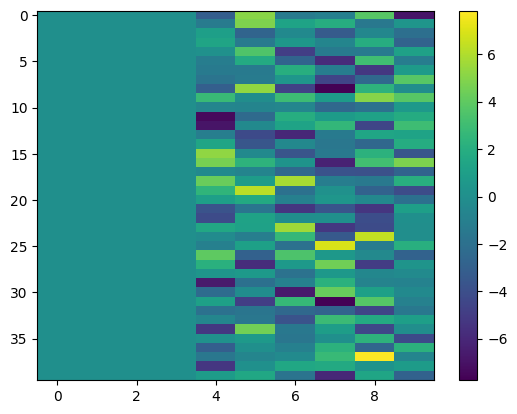

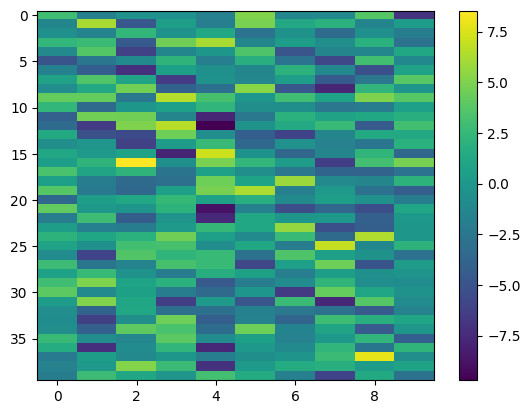

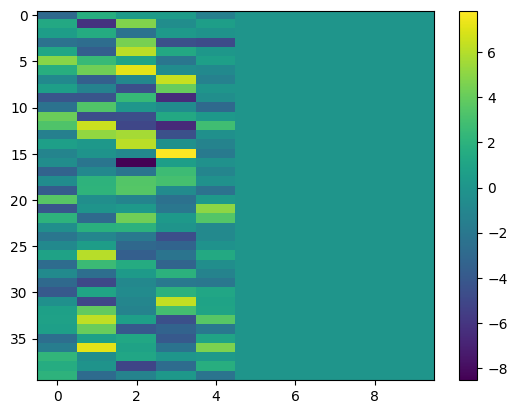

In [4]:
# compare vllm and torch outputs
import matplotlib.pyplot as plt


plt.imshow(output.numpy()[:, :, 0].T, aspect="auto")
plt.colorbar()
plt.show()

plt.imshow(y_torch_perm.numpy()[:, :, 0].T, aspect="auto")
plt.colorbar()
plt.show()

plt.imshow(output.numpy()[:, :, 0].T - y_torch_perm.numpy()[:, :, 0].T, aspect="auto")
plt.colorbar()
plt.show()
